In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET
import json
import os
import glob

In [ ]:
ROOT_PATH = "argos_runner/remote/results_4/results_4"

In [ ]:
def parse_run(run_dir):
    run_id = os.path.basename(run_dir)

    with open(os.path.join(run_dir, 'experiment_info.json'), 'r') as f:
        info = json.load(f)

    with open(os.path.join(run_dir, 'arena.json'), 'r') as f:
        arena = json.load(f)

    obstacles_count = len(arena["walls"])
        
    tree = ET.parse(os.path.join(run_dir, 'projet.argos'))
    light = tree.getroot().find('.//arena/light')
    target_x, target_y = map(float, light.get('position').split(',')[:2])
    
    csv_path = os.path.join(run_dir, 'experiment_data.csv')
    if os.path.getsize(csv_path) == 0:
        info.update({
            'num_agents': info['robots'], 'reached_count': 0, 'reached_ratio': 0.0,
            'mean_time_sec': 0.0, 'fastest_time_sec': 0.0, 'slowest_time_sec': 0.0,
            'total_distance': 0.0
        })
        return info

    df = pd.read_csv(csv_path, names=["robot_id", "step", "x", "y", "arrived"])
    
    GOAL_THRESH = 0.75
    TICKS_PER_SEC = info.get('ticks_per_second', 10.0)
    
    num_agents = len(df['robot_id'].unique())
    reached_count = 0
    times_to_target = []
    total_distance = 0.0
    
    for robot_id, group in df.groupby('robot_id'):
        group = group.sort_values('step')
        dist_to_target = np.sqrt((group['x'] - target_x)**2 + (group['y'] - target_y)**2)
        reached_mask = dist_to_target < GOAL_THRESH
        
        if reached_mask.any():
            reached_count += 1
            first_reached_idx = reached_mask.idxmax()
            steps_to_target = group.loc[first_reached_idx, 'step']
            times_to_target.append(steps_to_target)
            
            valid_steps = group[group['step'] <= steps_to_target]
            total_distance += np.sqrt(valid_steps['x'].diff()**2 + valid_steps['y'].diff()**2).sum()
        else:
            total_distance += np.sqrt(group['x'].diff()**2 + group['y'].diff()**2).sum()

    info.update({
        'num_agents': num_agents,
        'reached_count': reached_count,
        'reached_ratio': reached_count / num_agents if num_agents > 0 else 0,
        'mean_time_sec': (np.mean(times_to_target) / TICKS_PER_SEC) if times_to_target else 0,
        'fastest_time_sec': (np.min(times_to_target) / TICKS_PER_SEC) if times_to_target else 0,
        'slowest_time_sec': (np.max(times_to_target) / TICKS_PER_SEC) if times_to_target else 0,
        'total_distance': total_distance,
        "obstacles_count": obstacles_count,
        "run_id": int(run_id.split("_")[-1])
    })
    
    return info

In [ ]:
results_dirs = glob.glob(ROOT_PATH + "/run_*")
data = [parse_run(d) for d in results_dirs]
print(len(data))
df_results = pd.DataFrame(data)

df_results.to_csv("aggregated_results.csv", index=False)

print(df_results)

summary_stats = df_results.groupby(['arena_type', 'robots', 'algorithm']).agg({
    'reached_ratio': ['mean', 'std'],
    'mean_time_sec': ['mean', 'std'],
    'total_distance': ['mean', 'std'],
    'scatter_density': ['mean', 'std'],
    'scatter_size': ['mean', 'std']
}).reset_index()
summary_stats.to_csv("summary_statistics.csv")

500
      algorithm  length  ticks_per_second  total_ticks  robots  arena_size  \
0    flood_fill       1                 2            2       9        10.0   
1        projet       1                 2            2       9        10.0   
2           aco       1                 2            2       3        10.0   
3        projet       1                 2            2       7        10.0   
4           pso       1                 2            2       9        10.0   
..          ...     ...               ...          ...     ...         ...   
495  flood_fill       1                 2            2       7        10.0   
496         pso       1                 2            2      10        10.0   
497         pso       1                 2            2       4        10.0   
498    coverage       1                 2            2       9        10.0   
499  flood_fill       1                 2            2       5        10.0   

      seed arena_type  maze_width  maze_height  ...  scatte

In [ ]:
df_results[(df_results["reached_ratio"] == 0) & (df_results["algorithm"] == "projet")].sort_values(by="scatter_size")

,algorithm,length,ticks_per_second,total_ticks,robots,arena_size,seed,arena_type,maze_width,maze_height,...,scatter_density,num_agents,reached_count,reached_ratio,mean_time_sec,fastest_time_sec,slowest_time_sec,total_distance,obstacles_count,run_id
254,projet,1,2,2,7,10.0,83634,scatter,10,10,...,0.380240,7,0,0.0,0,0,0,0.103470,2735,257
115,projet,1,2,2,10,10.0,36487,scatter,10,10,...,0.424477,10,0,0.0,0,0,0,0.099162,1294,384
148,projet,1,2,2,2,10.0,28809,scatter,10,10,...,0.000475,2,0,0.0,0,0,0,0.013500,5,79
138,projet,1,2,2,8,10.0,49276,scatter,10,10,...,0.016889,8,0,0.0,0,0,0,0.092153,49,74
67,projet,1,2,2,7,10.0,5032,scatter,10,10,...,0.518335,7,0,0.0,0,0,0,0.084909,758,268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,projet,1,2,2,4,10.0,28972,scatter,10,10,...,0.074709,4,0,0.0,0,0,0,0.075503,6,374
161,projet,1,2,2,4,10.0,89792,scatter,10,10,...,0.283534,4,0,0.0,0,0,0,0.082916,10,31
287,projet,1,2,2,2,10.0,45333,scatter,10,10,...,0.015782,2,0,0.0,0,0,0,0.013500,4,424
89,projet,1,2,2,4,10.0,38185,scatter,10,10,...,0.374538,4,0,0.0,0,0,0,0.027000,10,479


In [ ]:
summary_stats

arena_type robots   algorithm reached_ratio      mean_time_sec       \
                                          mean  std          mean  std   
0     scatter      1         aco           0.0  0.0           0.0  0.0   
1     scatter      1    coverage           0.0  0.0           0.0  0.0   
2     scatter      1  flood_fill           0.0  0.0           0.0  0.0   
3     scatter      1      projet           0.0  0.0           0.0  0.0   
4     scatter      1         pso           0.0  0.0           0.0  0.0   
5     scatter      2         aco           0.0  0.0           0.0  0.0   
6     scatter      2    coverage           0.0  0.0           0.0  0.0   
7     scatter      2  flood_fill           0.0  0.0           0.0  0.0   
8     scatter      2      projet           0.0  0.0           0.0  0.0   
9     scatter      2         pso           0.0  0.0           0.0  0.0   
10    scatter      3         aco           0.0  0.0           0.0  0.0   
11    scatter      3    coverage           0.0  0.0           0.0  0.0   
12    scatter      3  flood_fill           0.0  0.0           0.0  0.0   
13    scatter      3      projet           0.0  0.0           0.0  0.0   
14    scatter      3         pso           0.0  0.0           0.0  0.0   
15    scatter      4         aco           0.0  0.0           0.0  0.0   
16    scatter      4    coverage           0.0  0.0           0.0  0.0   
17    scatter      4  flood_fill           0.0  0.0           0.0  0.0   
18    scatter      4      projet           0.0  0.0           0.0  0.0   
19    scatter      4         pso           0.0  0.0           0.0  0.0   
20    scatter      5         aco           0.0  0.0           0.0  0.0   
21    scatter      5    coverage           0.0  0.0           0.0  0.0   
22    scatter      5  flood_fill           0.0  0.0           0.0  0.0   
23    scatter      5      projet           0.0  0.0           0.0  0.0   
24    scatter      5         pso           0.0  0.0           0.0  0.0   
25    scatter      6         aco           0.0  0.0           0.0  0.0   
26    scatter      6    coverage           0.0  0.0           0.0  0.0   
27    scatter      6  flood_fill           0.0  0.0           0.0  0.0   
28    scatter      6      projet           0.0  0.0           0.0  0.0   
29    scatter      6         pso           0.0  0.0           0.0  0.0   
30    scatter      7         aco           0.0  0.0           0.0  0.0   
31    scatter      7    coverage           0.0  0.0           0.0  0.0   
32    scatter      7  flood_fill           0.0  0.0           0.0  0.0   
33    scatter      7      projet           0.0  0.0           0.0  0.0   
34    scatter      7         pso           0.0  0.0           0.0  0.0   
35    scatter      8         aco           0.0  0.0           0.0  0.0   
36    scatter      8    coverage           0.0  0.0           0.0  0.0   
37    scatter      8  flood_fill           0.0  0.0           0.0  0.0   
38    scatter      8      projet           0.0  0.0           0.0  0.0   
39    scatter      8         pso           0.0  0.0           0.0  0.0   
40    scatter      9         aco           0.0  0.0           0.0  0.0   
41    scatter      9    coverage           0.0  0.0           0.0  0.0   
42    scatter      9  flood_fill           0.0  0.0           0.0  0.0   
43    scatter      9      projet           0.0  0.0           0.0  0.0   
44    scatter      9         pso           0.0  0.0           0.0  0.0   
45    scatter     10         aco           0.0  0.0           0.0  0.0   
46    scatter     10    coverage           0.0  0.0           0.0  0.0   
47    scatter     10  flood_fill           0.0  0.0           0.0  0.0   
48    scatter     10      projet           0.0  0.0           0.0  0.0   
49    scatter     10         pso           0.0  0.0           0.0  0.0   

   total_distance           scatter_density           scatter_size            
             mean       std            mean       std         mean       st

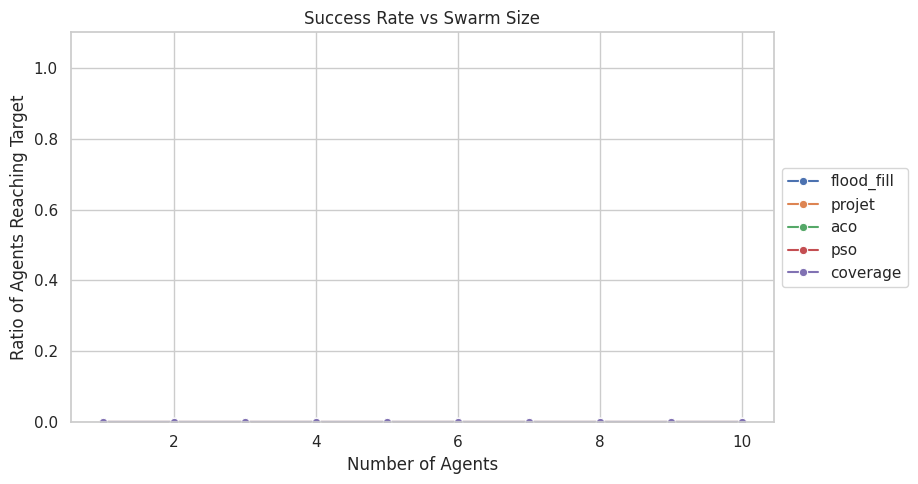

/tmp/ipykernel_81398/1793135000.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))


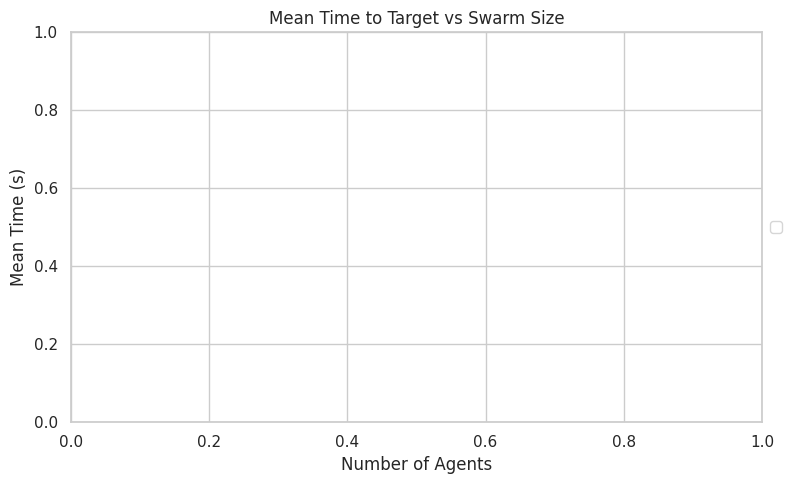

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.lineplot(data=df_results, x='robots', y='reached_ratio', hue='algorithm', marker='o')
plt.title('Success Rate vs Swarm Size')
plt.ylabel('Ratio of Agents Reaching Target')
plt.xlabel('Number of Agents')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

plt.figure(figsize=(8, 5))
df_reached = df_results[df_results['reached_count'] > 0]
sns.lineplot(data=df_reached, x='robots', y='mean_time_sec', hue='algorithm', marker='o')
plt.title('Mean Time to Target vs Swarm Size')
plt.ylabel('Mean Time (s)')
plt.xlabel('Number of Agents')
plt.tight_layout()
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

# plt.figure(figsize=(8, 5))
# df_scatter = df_results[(df_results['arena_type'] == 'scatter') & (df_results['mean_time_sec'] > 0)]
# df_scatter = df_scatter.copy()
# df_scatter['size_bin'] = pd.cut(df_scatter['scatter_size'], bins=10)
# df_binned = df_scatter.groupby('size_bin', observed=False)['mean_time_sec'].mean().reset_index()
# df_binned['bin_center'] = df_binned['size_bin'].apply(lambda x: x.mid)

# sns.lineplot(data=df_binned, x='bin_center', y='mean_time_sec', hue='algorithm', marker='o')
# plt.plot(df_binned['bin_center'], df_binned['mean_time_sec'], marker='o')
# plt.show()
# sns.lineplot(data=df_sorted, x='scatter_size', y='mean_time_sec', hue='algorithm', palette='viridis', marker='o')

# plt.title('Mean time vs obstacle density')
# plt.ylabel('Mean time (s)')
# plt.xlabel('Scatter size')
# plt.tight_layout()
# plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
# plt.show()

In [ ]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms

def render_arenas(results_dir="argos_runner/results"):
    arenas_render_path = "arenas_renders/"
    for index, run_dir in enumerate(glob.glob(os.path.join(results_dir, "run_*"))):
        arena_path = os.path.join(run_dir, 'arena.json')
        info_path = os.path.join(run_dir, 'experiment_info.json')
        
        if not os.path.exists(arena_path) or not os.path.exists(info_path):
            continue
            
        with open(arena_path, 'r') as f:
            arena = json.load(f)
        with open(info_path, 'r') as f:
            info = json.load(f)

        fig, ax = plt.subplots(figsize=(8, 8))

        for w in arena.get('walls', []):
            rect = patches.Rectangle(
                (w['x'] - w['sx'] / 2, w['y'] - w['sy'] / 2),
                w['sx'], w['sy'],
                color='black', alpha=0.5, zorder=2
            )
            t = transforms.Affine2D().rotate_around(w['x'], w['y'], np.radians(w['yaw'])) + ax.transData
            rect.set_transform(t)
            ax.add_patch(rect)

        target = arena.get('target')
        if target:
            ax.scatter(target['x'], target['y'], color="red", marker="o", s=50, zorder=5)

        start = arena.get('start')
        if start:
            x = start['min_x']
            y = start['min_y']
            sx = start['max_x'] - start['min_x']
            sy = start['max_y'] - start['min_y']
            rect = patches.Rectangle(
                (x, y),
                sx, sy,
                color='blue', alpha=0.5, zorder=2
            )
            t = transforms.Affine2D() + ax.transData
            rect.set_transform(t)
            ax.add_patch(rect)

        half_size = info.get('arena_size', 10.0) / 2.0
        ax.set_xlim(-half_size, half_size)
        ax.set_ylim(-half_size, half_size)
        
        title = f"{info.get('arena_type').capitalize()} Arena | Algo: {info.get('algorithm')} | Robots: {info.get('robots')} | Seed: {info.get('seed')}"
        if info.get('arena_type') == 'scatter':
            title += f" | Obs: {info.get('scatter_obstacles')}"
        
        ax.set_title(title)
        ax.grid(True)
        ax.set_aspect("equal")

        plt.savefig(os.path.join(arenas_render_path, f'arena_run_{index}.png'), bbox_inches='tight')
        plt.close()

In [ ]:
# render_arenas()

In [ ]:
def render_arena(id):
    run_dir = os.path.join(ROOT_PATH, f"run_{id}")
    with open(os.path.join(run_dir, 'arena.json'), 'r') as f:
        arena = json.load(f)
    
    with open(os.path.join(run_dir, 'experiment_info.json'), 'r') as f:
        info = json.load(f)
        
    tree = ET.parse(os.path.join(run_dir, 'projet.argos'))
    light = tree.getroot().find('.//arena/light')
    target_x, target_y = map(float, light.get('position').split(',')[:2])
    
    csv_path = os.path.join(run_dir, 'experiment_data.csv')
    if os.path.getsize(csv_path) == 0:
        info.update({
            'num_agents': info['robots'], 'reached_count': 0, 'reached_ratio': 0.0,
            'mean_time_sec': 0.0, 'fastest_time_sec': 0.0, 'slowest_time_sec': 0.0,
            'total_distance': 0.0
        })
        return info

    df = pd.read_csv(csv_path, names=["robot_id", "step", "x", "y", "arrived"])

    groups = df.groupby("robot_id")

    fig, ax = plt.subplots(figsize=(8, 8))

    # for robot_id, group in groups:
    #     line, = ax.plot(group["x"], group["y"]) # label=f"agent {robot_id}"
    #     c = line.get_color()
    #     ax.scatter(group["x"].iloc[0], group["y"].iloc[0], marker="o", s=20, color=c)
    #     ax.scatter(group["x"].iloc[-1], group["y"].iloc[-1], marker="x", s=40, color=c)

    for w in arena.get('walls', []):
        rect = patches.Rectangle(
            (w['x'] - w['sx'] / 2, w['y'] - w['sy'] / 2),
            w['sx'], w['sy'],
            color='black', alpha=0.5, zorder=2
        )
        t = transforms.Affine2D().rotate_around(w['x'], w['y'], np.radians(w['yaw'])) + ax.transData
        rect.set_transform(t)
        ax.add_patch(rect)

    target = arena.get('target')
    if target:
        ax.scatter(target['x'], target['y'], color="red", marker="o", s=50, label="target", zorder=5)

    start = arena.get('start')
    if start:
        x = start['min_x']
        y = start['min_y']
        sx = start['max_x'] - start['min_x']
        sy = start['max_y'] - start['min_y']
        rect = patches.Rectangle(
            (x, y),
            sx, sy,
            color='blue', alpha=0.5, zorder=2
        )
        t = transforms.Affine2D() + ax.transData
        rect.set_transform(t)
        ax.add_patch(rect)
        rect.set_label("Start area")

    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xticks(np.arange(-5, 6, 1))
    ax.set_yticks(np.arange(-5, 6, 1))
    ax.grid(True)
    ax.set_aspect("equal")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

    ax.set_title(f"Scatter size: {info["scatter_size"]:.2f}, Scatter density: {info["scatter_density"]:.2f}")
    # ax.set_title(f"{info["algorithm"]} - {info["robots"]} agents, scatter_size: {info["scatter_size"]:.2f}, scatter_density: {info["scatter_density"]:.2f}")

    plt.show()

237
argos_runner/remote/results_4/results_4/run_237


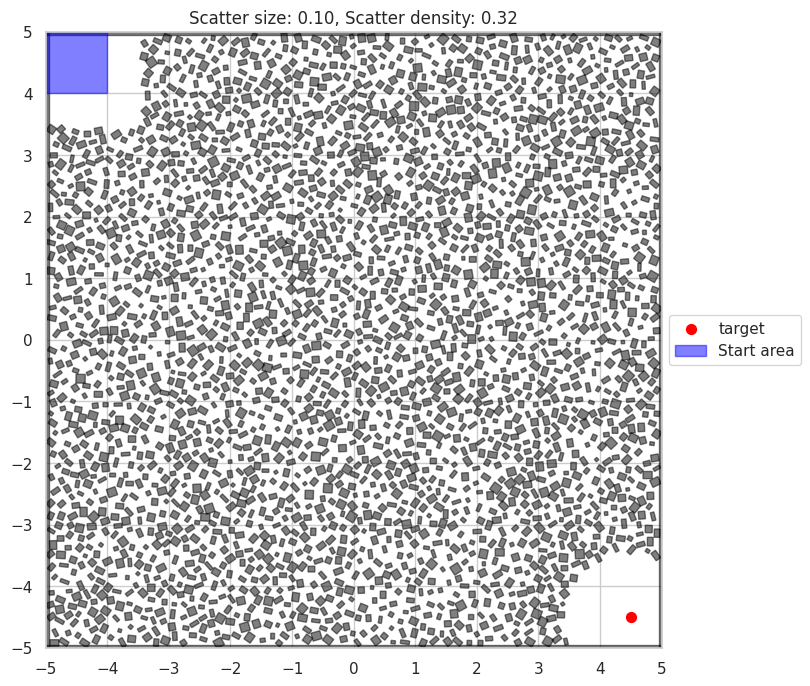

In [ ]:
# id = df_results[(df_results["algorithm"] == "coverage") & (df_results["robots"] > 1)].sort_values(by="reached_ratio", ascending = False).iloc[0]["run_id"]
# id = df_results.sort_values(by=["scatter_size", "scatter_density"], ascending = [True, True]).iloc[0]["run_id"]
id = df_results.loc[
    (df_results["scatter_density"] + 1/df_results["scatter_size"]).idxmax()
]["run_id"]
print(id)
render_arena(id)

In [ ]:
df = df_results.copy()[df_results["obstacles_count"] > 4]
df["d_norm"] = (df["scatter_density"] - df["scatter_density"].min()) / (
    df["scatter_density"].max() - df["scatter_density"].min()
)
df["s_norm"] = (df["scatter_size"] - df["scatter_size"].min()) / (
    df["scatter_size"].max() - df["scatter_size"].min()
)

corners = {
    "bottom_left":  (0, 0),
    "bottom_right": (1, 0),
    "top_left":     (0, 1),
    "top_right":    (1, 1),
}

selected = {}

for name, (cx, cy) in corners.items():
    dist = (df["d_norm"] - cx)**2 + (df["s_norm"] - cy)**2
    idx = dist.idxmin()
    selected[name] = df.loc[idx]

corner_run_ids = {k: v["run_id"] for k, v in selected.items()}
corner_run_ids

NameError: name 'df_results' is not defined

In [ ]:
for id in corner_run_ids.values():
    render_arena(id)

NameError: name 'corner_run_ids' is not defined

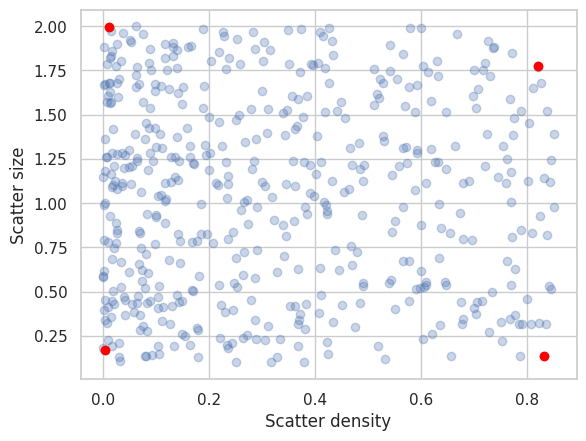

In [ ]:
plt.figure()
plt.scatter(df_results["scatter_density"], df_results["scatter_size"], alpha=0.3)

for name, row in selected.items():
    plt.scatter(row["scatter_density"], row["scatter_size"], color="red")
    # plt.text(row["scatter_density"], row["scatter_size"], name)

plt.xlabel("Scatter density")
plt.ylabel("Scatter size")
plt.show()